In part 2, we used `solve_ivp` to solve a single differential equation. Now, we will use this technique to solve a differential system and interprete results.

&#9989;&nbsp; **Question 3.1 (25 points)**: The SIR epidemic model is one of the simplest compartmental models, and many models are derivatives of this basic form(https://en.wikipedia.org/wiki/Compartmental_models_in_epidemiology). The model consists of three compartments: 
The number of susceptible individuals (S), the number of infectious individuals (I), and the number of removed (and immune) or deceased individuals (R). When we account for the vaccination impacts on the model, we have the following SIRVI model:
$$ \frac{dS}{dt} = -\beta SI -\mu S, $$
$$ \frac{dI}{dt} = \beta SI +\alpha VI -\gamma I, $$
$$ \frac{dV}{dt} = \mu S -\alpha VI, $$
$$ \frac{dR}{dt} = \gamma I ,$$

where $V$ is the number of vaccinated individuals, the parameters $\beta$ represents the infectious rate of susceptibles, $\gamma$ is the recovery rate, $\mu$ is the vaccine rate of susceptibles, and $\alpha$ is the infectious rate of vaccinated. We assume will use day as our unit of time, $t$. This means that, for example,$t=2$ would be 2 days.

Assuming the parameters $\alpha =0.2, \beta =0.01, \gamma = 0.5$, and $\mu = 0.4$ with the following initial conditions:

* $S(0) = 130$
* $I(0) = 40$
* $V(0) = 50$
* $R(0) = 0$
  
Evolve the model for 15 days using a timestep of $\Delta t = 0.01$ days. In the following,the code have been provided and when you run these code, you will obtain the following plot. In the following you need tointeprate results based on your observations. 
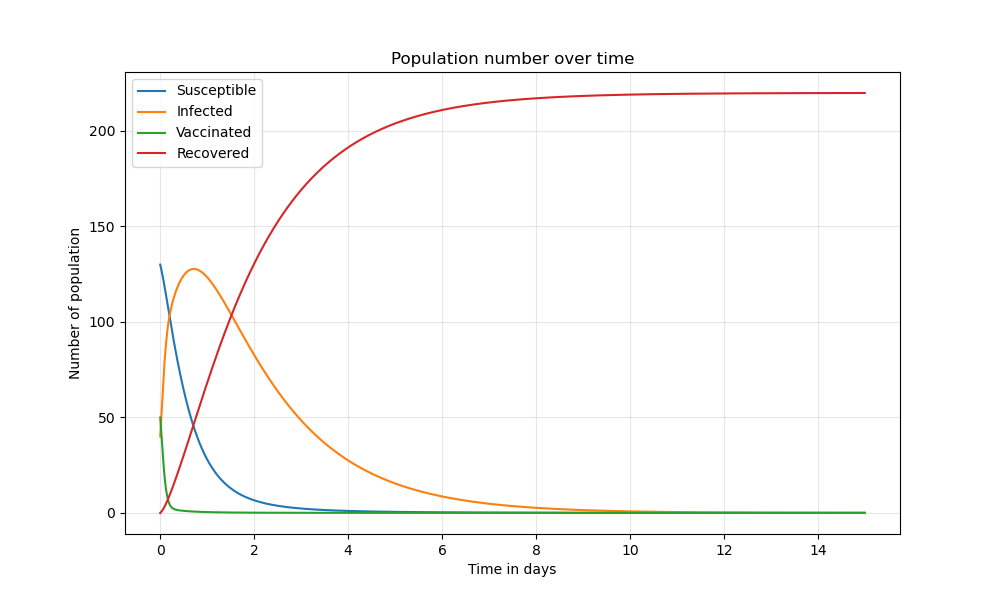





In [3]:
# put your code here
##### The import commands you need are provided here
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt

In [42]:
# Step 1. Define the Derivative Function
def derivatives(t, y):
    S, I, V, R = y # 
    a = 0.2 
    b = 0.01 
    g = 0.6 
    m = 0.4 
    
    dSdt = -(b * S * I) - (m * S) 
    dIdt = (b * S * I) + (a * V * I) - (g * I) 
    dVdt = (m * S) - (a * V * I) 
    dRdt = (g * I) 

    return [dSdt, dIdt, dVdt, dRdt] 

In [43]:
# Step 2. Given the Initial Conditions
S0 = 130  
I0 = 40 
V0 = 50  
R0 = 0 

initial_conditions = [S0, I0, V0, R0] 

In [44]:
#Step 3. The time range for the system and time steps
tinit = 0 
tmax = 15
time_step = .01

# Generate an array of times using np.arange()
times = np.arange(tinit, tmax, time_step)

In [45]:
#Step 4. Calling solv_ivp Function
sol = solve_ivp(derivatives, (0,times[-1]), initial_conditions, t_eval = times)

In [46]:
#Step 5. Unpack the Numerical Solutions

t_result = sol.t 

numerical_S = sol.y[0,:] 
numerical_I = sol.y[1,:] 
numerical_V = sol.y[2,:] 
numerical_R = sol.y[3,:] 

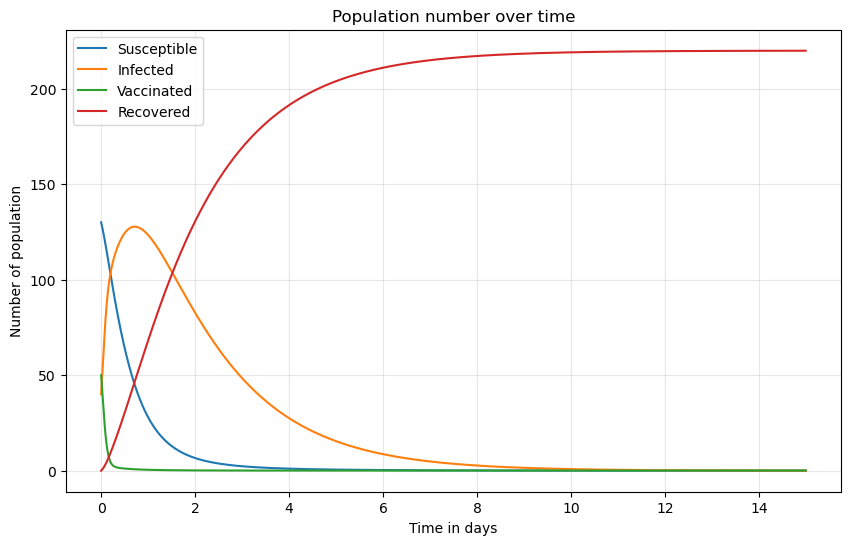

In [47]:
#Step 6. Plots of Each Component
plt.figure(figsize=(10, 6))
plt.plot(t_result, numerical_S, label='Susceptible')
plt.plot(t_result, numerical_I, label='Infected')
plt.plot(t_result, numerical_V, label='Vaccinated')
plt.plot(t_result, numerical_R, label='Recovered')

plt.title('Population number over time')
plt.xlabel('Time in days')
plt.ylabel('Number of population')
plt.legend()
plt.grid(True, alpha = 0.3)
#plt.show()

#plt.savefig("numerical.png")

&#9989;&nbsp; **Part 3.1 (9 points)** 
Based on the plot, answer the following questions:
1. Which categories of people are likely to increase and which categories are likely to decrease in the initial stage?(3 points)
2. The number of infected individuals will decrease after a certain period. What is the most likely reason for this? (3 points)
3. When is the best time to administer vaccinations?(3 points)

In [ ]:
#Put your answer here

In [ ]:
#Answer
#1. In the initial stage, the number of infected and recovered people will increase, while the number of susceptible and vaccinated people will decrease.（3 points)
#2. Because, after certain period, the infected individuals will recover.(3 points)
#3.The best time should be at the begining of the outbreak.(3 points)

&#9989;&nbsp; **Part 3.2 (6 points)** 
Assuming we only change the parameter $\alpha =0$ which means vaccinated people will not get infected.

After running the code provided above, you will obtain the following plot.
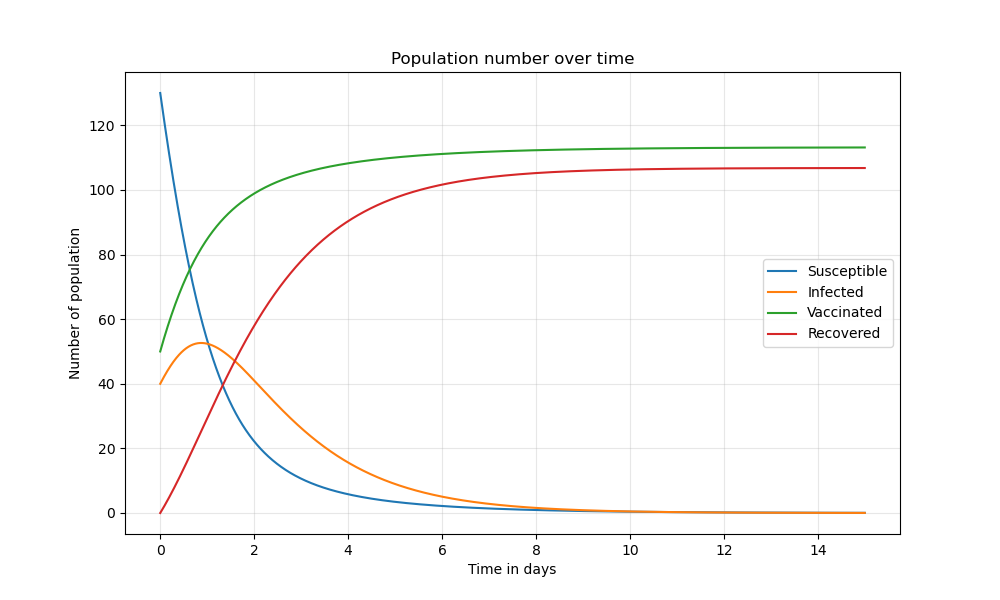

Based on the plots provided above, answer the following questions.
1. Do you think vaccination is a good strategy for controlling the spread of infectious diseases? (3 points)
2. Do recovered individuals need to get vaccinated in this scenario? (3 points)

In [ ]:
#Put your answer here

In [48]:
#Answer
#1.The best strategy should be to administer vaccinations, as people will not get infected after receiving them. (3 poitns)
#2. Recovered individuals do not need to get vaccinated.(3 points)